In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)

Shape: (1200, 9)

First 5 rows:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  

Data Types:
transaction_date         str
store_id               int64
store_size               str
location_type            str
promotion_type           str

In [26]:
# Task 1: Date Feature Engineering
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Binary feature: is_month_end (1 if day >= 25)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample to confirm new columns
print("Sample with new date features:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10))

Sample with new date features:
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0


## Task 1: Date Feature Engineering

Four new features were extracted from `transaction_date`:
- `year` — captures yearly trends
- `month` — captures seasonal patterns (e.g. festive months)
- `day_of_week` — captures weekly shopping patterns (0=Monday, 6=Sunday)
- `is_month_end` — binary flag (1 if day ≥ 25), captures end-of-month spending behaviour when customers may be paid

In [27]:
# Task 2: Temporal Train-Test Split
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_index = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split_index]
test = df_sorted.iloc[split_index:]

print("Train size:", train.shape)
print("Test size:", test.shape)
print("Train date range:", train['transaction_date'].min(), "to", train['transaction_date'].max())
print("Test date range:", test['transaction_date'].min(), "to", test['transaction_date'].max())

Train size: (960, 13)
Test size: (240, 13)
Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


## Task 2: Temporal Train-Test Split

- **Train set:** 960 records (2022-01-01 to 2024-06-11)
- **Test set:** 240 records (2024-06-12 to 2024-12-31)

**Why a random split is inappropriate for time-ordered data:**

A random split would allow the model to train on future data and test on past data, causing data leakage. For example, the model could learn patterns from December 2024 and then be tested on June 2024 — an unrealistic scenario. In real deployment, a model only has access to past data when making future predictions. A temporal split correctly simulates this by ensuring the test set is always chronologically after the training set.

In [28]:
# Task 3: Preprocessing Pipeline
feature_cols = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                'year', 'month', 'day_of_week', 'is_month_end',
                'store_size', 'location_type', 'promotion_type']

categorical_cols = ['store_size', 'location_type', 'promotion_type']
numerical_cols = ['store_id', 'is_weekend', 'is_festival', 'competition_density',
                  'year', 'month', 'day_of_week', 'is_month_end']

X_train = train[feature_cols]
X_test = test[feature_cols]
y_train = train['items_sold']
y_test = test['items_sold']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

print("Pipeline defined successfully!")
print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

Pipeline defined successfully!
Categorical features: ['store_size', 'location_type', 'promotion_type']
Numerical features: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


In [29]:
# Task 4: Train models inside pipeline
# Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Regressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

# Fit both models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression:")
print(f"  RMSE: {lr_rmse:.2f}")
print(f"  MAE:  {lr_mae:.2f}")
print("\nRandom Forest Regressor:")
print(f"  RMSE: {rf_rmse:.2f}")
print(f"  MAE:  {rf_mae:.2f}")

Linear Regression:
  RMSE: 27.12
  MAE:  21.05

Random Forest Regressor:
  RMSE: 30.72
  MAE:  24.16


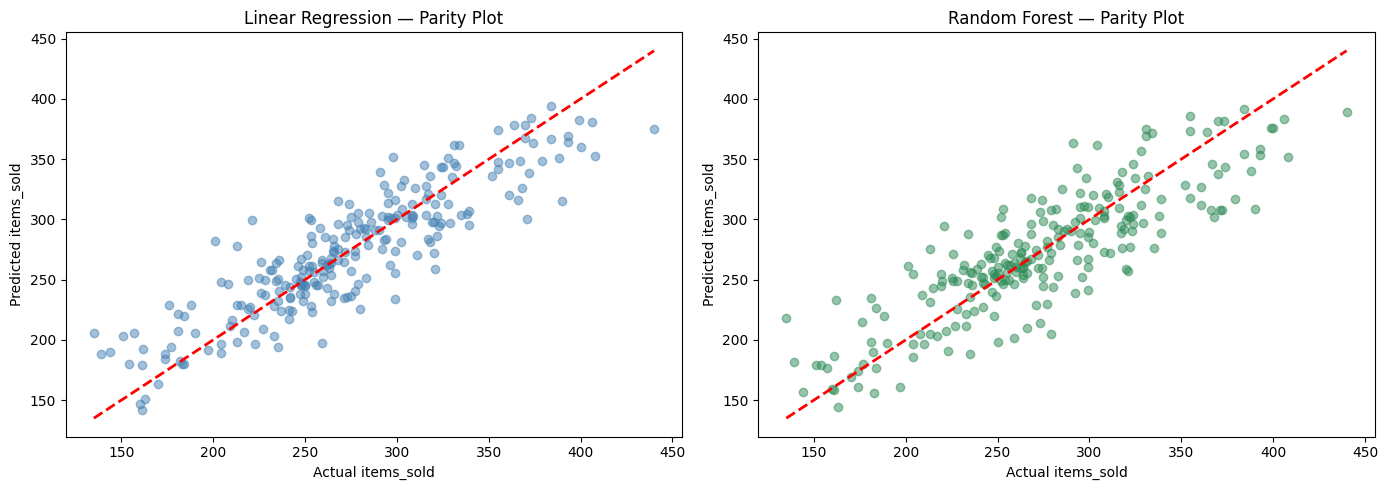

Top 5 Most Important Features:
                feature  importance
13          is_festival    0.173420
2      store_size_small    0.165968
5   location_type_urban    0.108938
17          day_of_week    0.087555
12           is_weekend    0.059983


In [30]:
# Parity plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression parity plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title('Linear Regression — Parity Plot')
axes[0].set_xlabel('Actual items_sold')
axes[0].set_ylabel('Predicted items_sold')

# Random Forest parity plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_title('Random Forest — Parity Plot')
axes[1].set_xlabel('Actual items_sold')
axes[1].set_ylabel('Predicted items_sold')

plt.tight_layout()
plt.show()

# Feature importances from Random Forest
ohe_features = list(rf_pipeline.named_steps['preprocessor']
                    .named_transformers_['cat'].get_feature_names_out(categorical_cols))
all_features = ohe_features + numerical_cols

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

print("Top 5 Most Important Features:")
print(feat_imp.head())

## Task 4: Model Training and Evaluation

| Model | RMSE | MAE |
|---|---|---|
| Linear Regression | 27.12 | 21.05 |
| Random Forest Regressor | 30.72 | 24.16 |

**Linear Regression performs better** on this dataset, achieving lower RMSE and MAE. This suggests the relationship between features and items_sold is largely linear.

**Parity Plots:** Both models show predictions reasonably aligned with the diagonal reference line, indicating decent predictive ability. Linear Regression shows tighter clustering around the diagonal.

**Top 5 Most Important Features (Random Forest):**
1. `is_festival` (0.173) — Festival periods drive the most sales
2. `store_size_small` (0.166) — Store size significantly affects sales volume
3. `location_type_urban` (0.109) — Urban stores show distinct sales patterns
4. `day_of_week` (0.088) — Day of week influences shopping behaviour
5. `is_weekend` (0.060) — Weekend effect on sales volume